# 05 — Explainability

Visualise which image regions drive model predictions.  The method is chosen automatically based on the backbone architecture:

| Architecture | Method | How it works |
|---|---|---|
| **ResNet / EfficientNet** | GradCAM | Backpropagates through the last conv block; gradients weight the activation maps spatially |
| **ViT (DINO / timm)** | CLS attention map | Reads the softmax attention weights of the CLS token toward each image patch from the last self-attention block, averaged over heads |

Green title = correct prediction.  Red title = misclassification.

### Prerequisites

You need at least one trained checkpoint:

```bash
python -m scripts.ulcer.run_data_efficiency --subset-ratios 1.0 --seeds 42 --epochs 5
python -m scripts.mes.run_data_efficiency   --subset-ratios 1.0 --seeds 42 --epochs 5
```

In [11]:
import sys
from pathlib import Path

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch

from src.config import get_img_size
from src.data.dataloader import get_test_loader
from src.models.classifier import ClassifierModel
from src.utils import get_device
from src.visualization import visualize_predictions

## Configuration

Point `CHECKPOINT_PT` at a `best.pt` file produced by the training scripts.

In [31]:
# ── Task ──────────────────────────────────────────────────────────────────────
TASK = "ulcer"          # "ulcer" | "mes"

# ── Model filter (optional) ───────────────────────────────────────────────────
# None  → most recent checkpoint for TASK (any model)
# str   → most recent checkpoint for TASK + this model name
MODEL: str | None = "vits16_imagenet"
# MODEL = "vits16_imagenet"

# ── Explicit checkpoint (optional) ────────────────────────────────────────────
# Overrides TASK and MODEL entirely when set.
# Layout: output/{task}/models/{model}/{freeze}/{head_type}/{timestamp}/best.pt
CHECKPOINT_PT: Path | None = None
# CHECKPOINT_PT = ROOT / "output/ulcer/models/vits16_imagenet/0/linear/20260605_162602/best.pt"

# ── Data root ─────────────────────────────────────────────────────────────────
DATA_ROOT = ROOT / "data"

# ── Preprocessing ─────────────────────────────────────────────────────────────
EQUALIZE = False  # set True if the model was trained with histogram equalization

# ── Visualisation settings ────────────────────────────────────────────────────
N_SAMPLES = 8     # images to display
ALPHA     = 0.45  # heatmap opacity (0 = original only → 1 = heatmap only)
NCOLS     = 4     # grid columns

# Label maps
ULCER_LABELS = {0: "Normal", 1: "Ulcer"}
MES_LABELS   = {0: "Mayo 0", 1: "Mayo 1", 2: "Mayo 2", 3: "Mayo 3"}

## Load Model

In [32]:
# ── Resolve checkpoint ────────────────────────────────────────────────────────
# Priority: CHECKPOINT_PT > MODEL > TASK (most recent in each case)
_ckpt = CHECKPOINT_PT
if _ckpt is None:
    _search_root = ROOT / "output" / TASK / "models"
    if MODEL is not None:
        _search_root = _search_root / MODEL
    _candidates = sorted(
        _search_root.glob("**/best.pt"),
        key=lambda p: p.parts[-2],  # YYYYMMDD_HHMMSS timestamp dir
    )
    if not _candidates:
        _desc = f"{TASK}/{MODEL}" if MODEL else TASK
        print(f"No checkpoints found under output/{_desc}/models/\nTrain a model first.")
    else:
        _ckpt = _candidates[-1]
        print(f"Auto-selected (most recent): {_ckpt}")

if _ckpt is not None and not _ckpt.exists():
    print(f"Checkpoint not found: {_ckpt}")
    _ckpt = None

if _ckpt is not None:
    # ── Parse architecture from checkpoint path ────────────────────────────────
    # Layout: .../output/{task}/models/{model_name}/{freeze}/{head_type}/{ts}/best.pt
    parts           = _ckpt.parts
    ckpt_head_type  = parts[-3]      # e.g. "linear"
    ckpt_freeze     = int(parts[-4]) # e.g. 0 or -1
    ckpt_model_name = parts[-5]      # e.g. "vits16_imagenet"

    # task from path when CHECKPOINT_PT is set explicitly, else from TASK
    task = next((p for p in parts if p in ("ulcer", "mes")), TASK)

    num_classes  = 1 if task == "ulcer" else 4
    LABEL_MAP    = ULCER_LABELS if task == "ulcer" else MES_LABELS
    MANIFEST_CSV = DATA_ROOT / task / "splits" / "dataset_manifest.csv"

    device = get_device()

    model = ClassifierModel(
        base_model    = ckpt_model_name,
        num_classes   = num_classes,
        optimizer     = "Adam",   # training-only — does not affect inference
        learning_rate = 1e-4,     # training-only — does not affect inference
        freeze_layers = ckpt_freeze,
        head_type     = ckpt_head_type,
    )
    state = torch.load(_ckpt, map_location=device, weights_only=True)
    model.base_model.load_state_dict(state)
    model.base_model.to(device)
    model.base_model.eval()

    from src.visualization.explainability import _vit_module
    method = "Attention map" if _vit_module(model) is not None else "GradCAM"
    print(f"Task    : {task}")
    print(f"Model   : {ckpt_model_name}  (freeze={ckpt_freeze}, head={ckpt_head_type})")
    print(f"Classes : {num_classes}  →  {LABEL_MAP}")
    print(f"Manifest: {MANIFEST_CSV}")
    print(f"Device  : {device}")
    print(f"Method  : {method}")

Auto-selected (most recent): ..\output\ulcer\models\vits16_imagenet\0\linear\20260605_162602\best.pt


Using cache found in C:\Users\yannb/.cache\torch\hub\facebookresearch_dino_main
16:56:29 | INFO     | src.models.classifier | No layers frozen — full fine-tuning.


Task    : ulcer
Model   : vits16_imagenet  (freeze=0, head=linear)
Classes : 1  →  {0: 'Normal', 1: 'Ulcer'}
Manifest: ..\data\ulcer\splits\dataset_manifest.csv
Device  : cuda:0
Method  : Attention map


## Load Test DataLoader

In [33]:
if _ckpt is not None:
    test_loader = get_test_loader(
        manifest_path = MANIFEST_CSV,
        data_dir      = DATA_ROOT / task / "processed",
        img_size      = get_img_size(ckpt_model_name),
        batch_size    = 16,
        num_workers   = 0,
        equalize      = EQUALIZE,
    )
    print(f"Test samples: {len(test_loader.dataset)}")

Test samples: 1108


## All Predictions

Green title = correct prediction.  Red title = misclassification.

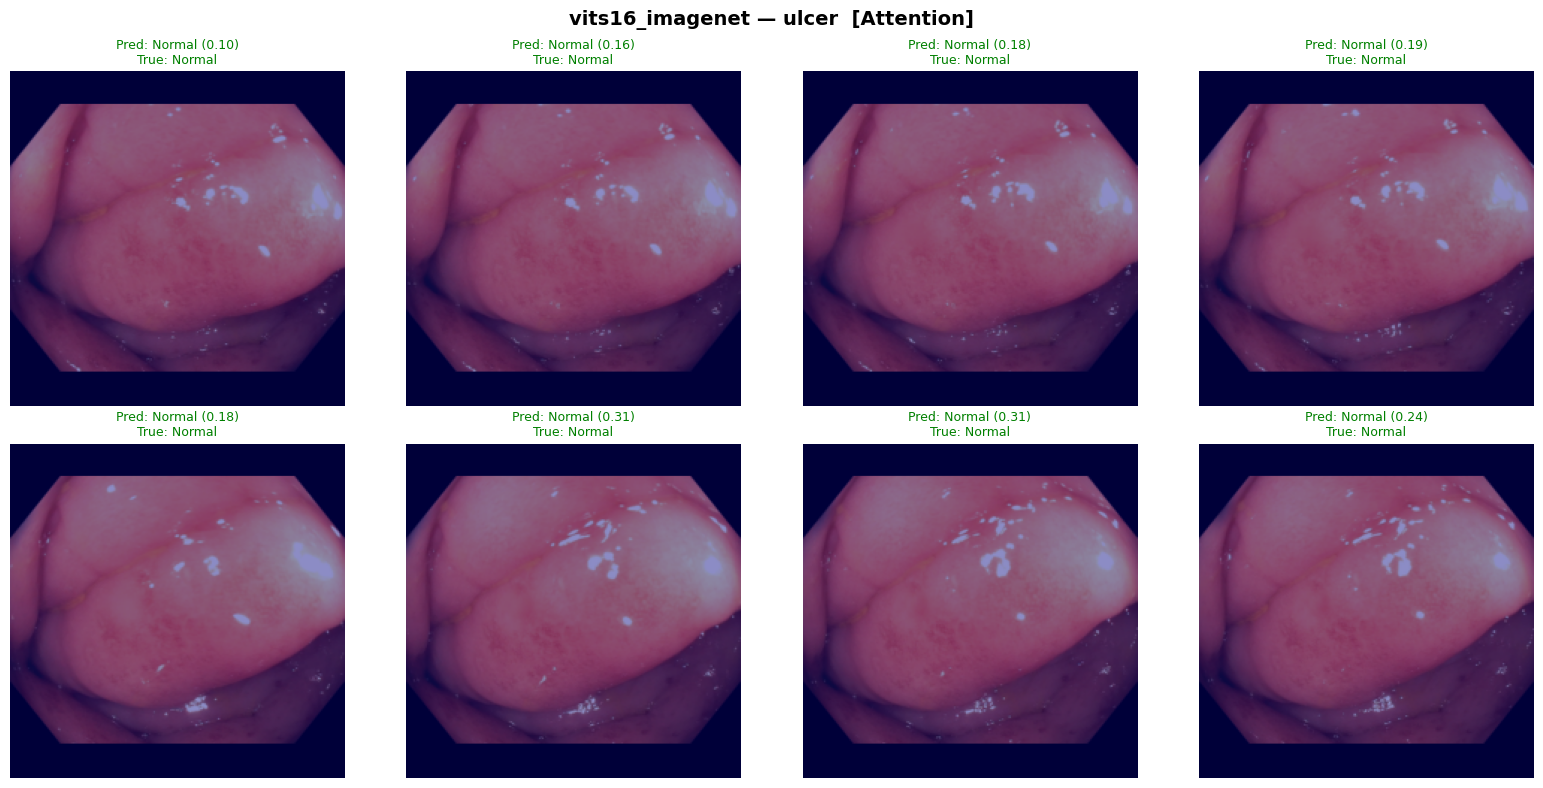

In [34]:
if _ckpt is not None:
    visualize_predictions(
        model      = model,
        dataloader = test_loader,
        label_map  = LABEL_MAP,
        device     = device,
        n_samples  = N_SAMPLES,
        alpha      = ALPHA,
        title      = f"{ckpt_model_name} — {task}",
        ncols      = NCOLS,
    )

In [35]:
%matplotlib inline

## Misclassifications Only

Filter the test set to frames where the model is wrong.

Misclassifications: 395 / 1108


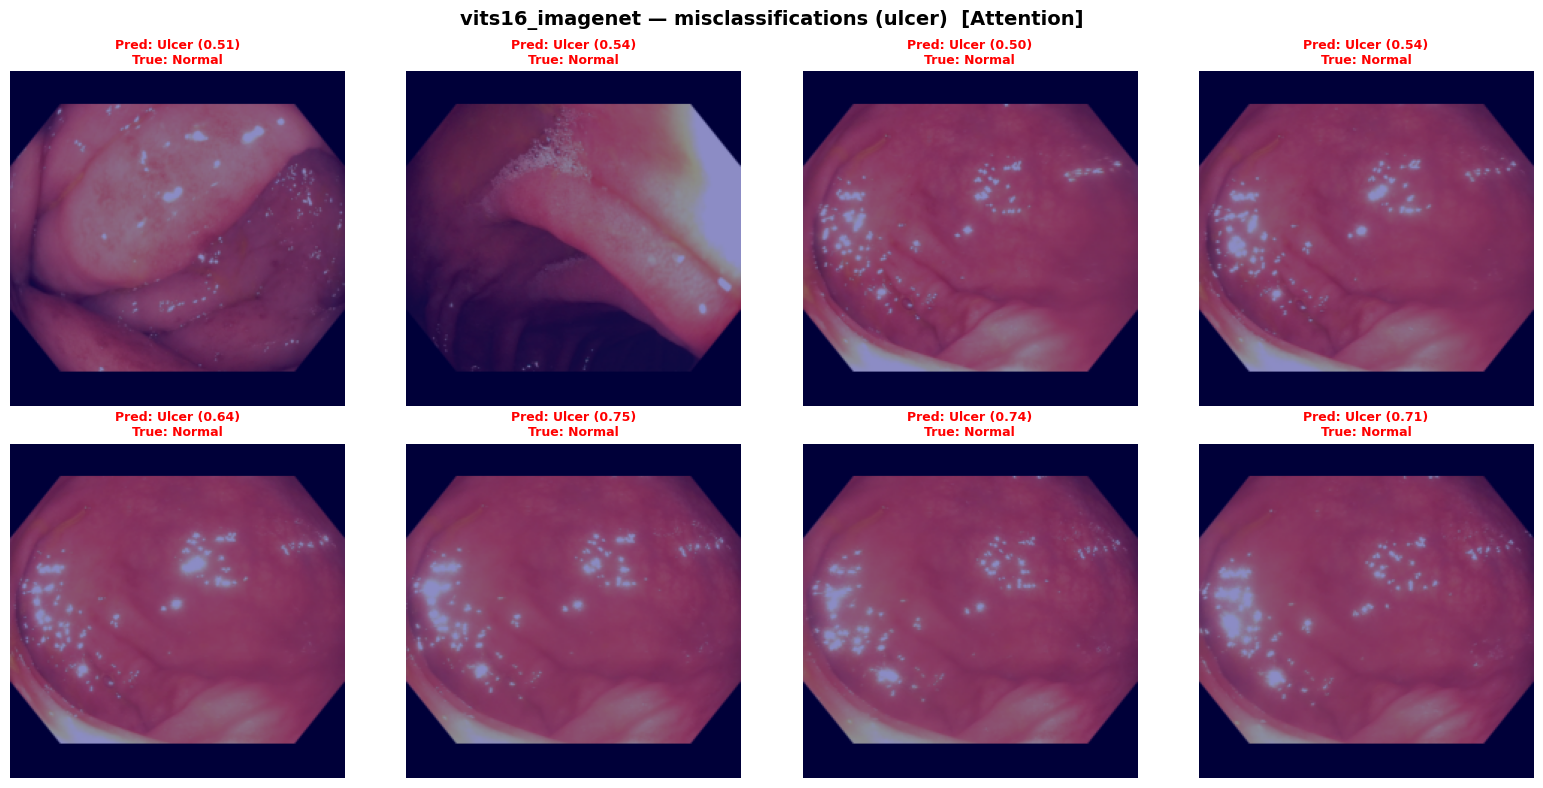

In [36]:
if _ckpt is not None:
    import numpy as np
    import torch.utils.data as tud

    all_imgs, all_labels = [], []
    for batch in test_loader:
        all_imgs.append(batch[0])
        all_labels.append(batch[1])
    all_imgs   = torch.cat(all_imgs)
    all_labels = torch.cat(all_labels)

    preds = []
    with torch.no_grad():
        for i in range(0, len(all_imgs), 32):
            logits = model.base_model(all_imgs[i:i+32].to(device))
            if hasattr(logits, "logits"):
                logits = logits.logits
            if model.number_classes == 1:
                preds.append((torch.sigmoid(logits.squeeze(1)) >= model.threshold).long().cpu())
            else:
                preds.append(logits.argmax(dim=1).cpu())
    preds = torch.cat(preds)

    wrong_mask = preds != all_labels
    n_wrong    = int(wrong_mask.sum())
    print(f"Misclassifications: {n_wrong} / {len(all_labels)}")

    if n_wrong == 0:
        print("No misclassifications — perfect test set performance!")
    else:
        wrong_loader = tud.DataLoader(
            tud.TensorDataset(all_imgs[wrong_mask], all_labels[wrong_mask]),
            batch_size=N_SAMPLES, shuffle=False,
        )
        visualize_predictions(
            model      = model,
            dataloader = wrong_loader,
            label_map  = LABEL_MAP,
            device     = device,
            n_samples  = min(N_SAMPLES, n_wrong),
            alpha      = ALPHA,
            title      = f"{ckpt_model_name} — misclassifications ({task})",
            ncols      = NCOLS,
        )

## GradCAM — Target Class (CNN only)

Force GradCAM to highlight evidence for a specific class regardless of the
actual prediction.  Useful for understanding what the model associates with
a given label.

> **ViT models**: `class_idx` is ignored — the attention map is class-agnostic
> (it reflects what the CLS token attends to, not a gradient toward any class).

ViT model detected — showing attention map (class_idx=1 ignored).
The attention map is class-agnostic: it shows what the CLS token attends to.


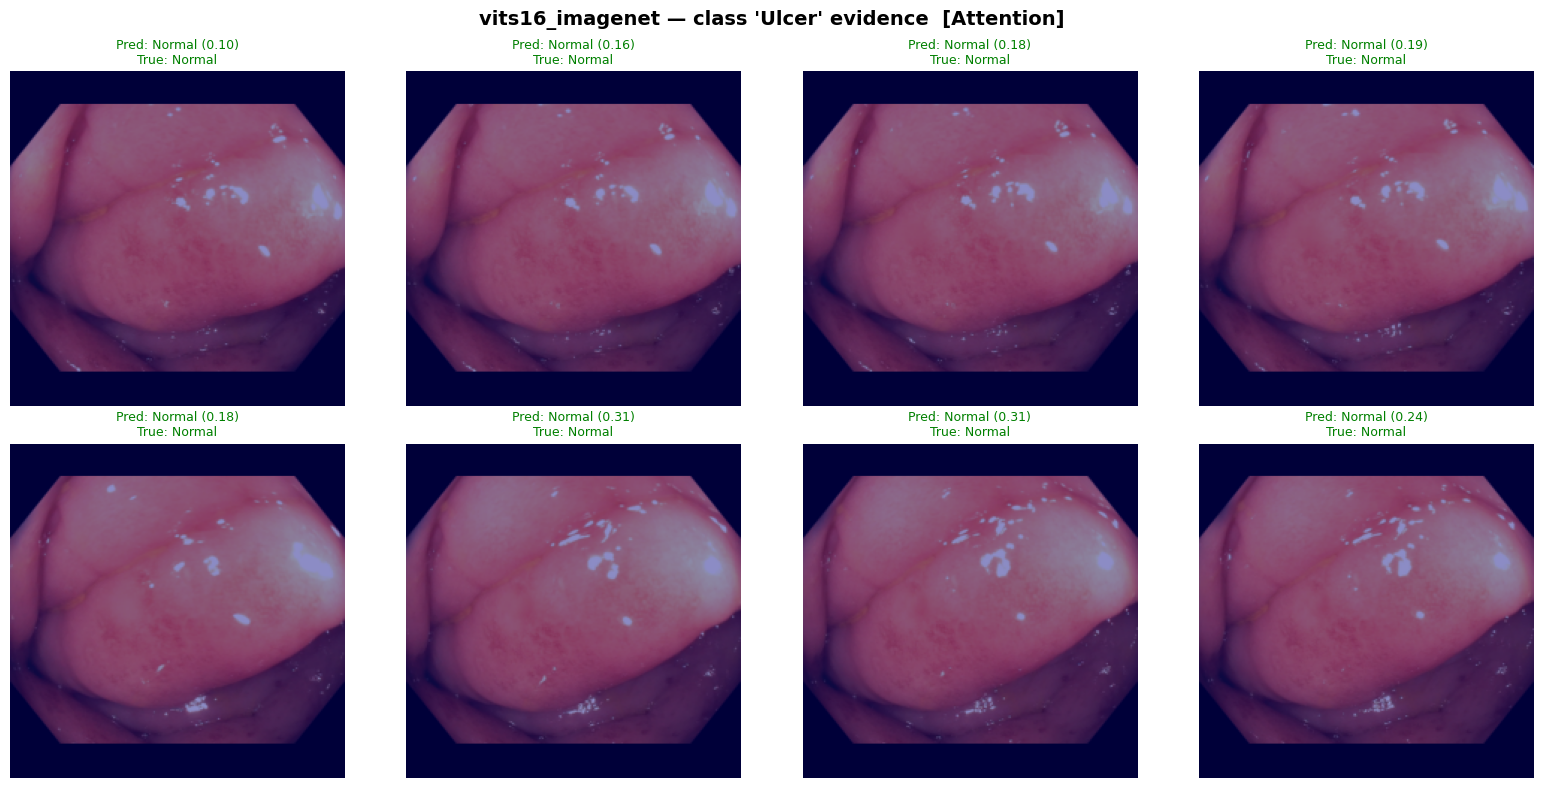

In [37]:
if _ckpt is not None:
    TARGET_CLASS = 1  # e.g. 1 = Ulcer, or 2 = Mayo 2

    from src.visualization.explainability import _vit_module
    if _vit_module(model) is not None:
        print(
            f"ViT model detected — showing attention map (class_idx={TARGET_CLASS} ignored).\n"
            "The attention map is class-agnostic: it shows what the CLS token attends to."
        )

    visualize_predictions(
        model      = model,
        dataloader = test_loader,
        label_map  = LABEL_MAP,
        device     = device,
        n_samples  = N_SAMPLES,
        alpha      = ALPHA,
        title      = f"{ckpt_model_name} — class '{LABEL_MAP.get(TARGET_CLASS, TARGET_CLASS)}' evidence",
        ncols      = NCOLS,
        class_idx  = TARGET_CLASS,
    )